NCR Analysis

# Libraries

In [2]:
import pandas as pd

# HEIs

In [ ]:
# Load the CSV file
df = pd.read_csv("NCR TESDA DATA.csv")

# Total number of graduates from HEIs
hei_count = df[df["Class Name"] == "HEIs"].shape[0]

# Total number of graduates from HEIs
hei_df = df[df["Class Name"] == "HEIs"]
total_graduates = hei_df["Graduates"].sum()

print("Number of rows with 'HEIs' in Class Name:", hei_count)
print("Total number of graduates under HEIs:", total_graduates)

Number of rows with 'HEIs' in Class Name: 38
Total number of graduates under HEIs: 2121


# TVETs

In [6]:
unique_values = df["Class Name"].unique()
unique_values

array(['TTI (School)', 'TVIs', 'HEIs', 'LGU', 'TTI (PTC)', 'LCU',
       'Enterprise/Company', 'NGO/Foundation ', 'TTI (RTC)'], dtype=object)

In [15]:
# Define which class names count as TVET
tvet_classes = ["TVIs", "TTI (School)", "TTI (PTC)", "LGU"]

# Number of TVET schools
tvet_count = df[df["Class Name"].isin(tvet_classes)].shape[0]
print("Number of TVET schools:", tvet_count)

# Number of graduates from TVET schools
tvet_df = df[df["Class Name"].isin(tvet_classes)]
total_graduates = tvet_df["Graduates"].sum()
print("Total number of graduates from TVET schools:", total_graduates)



Number of TVET schools: 794
Total number of graduates from TVET schools: 105553


# Ignore This

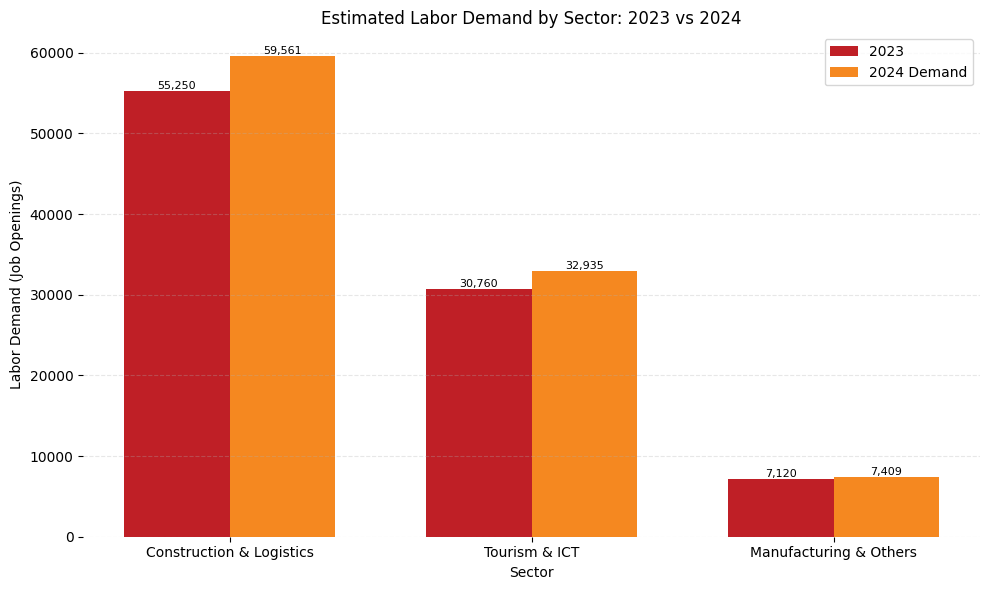

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Your estimates (from earlier)
sectors = ["Construction & Logistics",  "Tourism & ICT", "Manufacturing & Others"]
demand_2024 = [59561, 32935, 7409]
# Proxy estimated 2023 demand (from our backward scaling earlier)
demand_2023 = [55250, 30760, 7120]

x = np.arange(len(sectors))  # positions for sectors
width = 0.35  # width of bars

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, demand_2023, width, label='2023', color='#bf1f26')
bars2 = ax.bar(x + width/2, demand_2024, width, label='2024 Demand', color='#f58820ff')

# Labels, title, etc.
ax.set_xlabel("Sector")
ax.set_ylabel("Labor Demand (Job Openings)")
ax.set_title("Estimated Labor Demand by Sector: 2023 vs 2024")
ax.set_xticks(x)
ax.set_xticklabels(sectors, rotation=0, ha='center')
ax.legend()

# Optionally, annotate bar heights
def annotate_bars(bars):
    for b in bars:
        height = b.get_height()
        ax.annotate(f'{height:,}',
                    xy=(b.get_x() + b.get_width()/2, height),
                    xytext=(0, 0),  # offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)

annotate_bars(bars1)
annotate_bars(bars2)

ax.spines[['right', 'left', 'bottom', 'top']].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.3)



plt.tight_layout()
plt.show()


# Year to Year Growth

In [15]:
import pandas as pd

# Reload the aggregated NCR dataset
aggregated = pd.read_csv("aggregated_ncr.csv")

# Remove duplicate rows based on Job Sector
aggregated_clean = aggregated.drop_duplicates(subset=["Job Sector"])

# Get top 5 sectors by Total employment
top5 = aggregated_clean.nlargest(5, "Total")[["Job Sector", "Total"]]
top5


,Job Sector,Total
5,Administrative and Support Service Activities ...,794753
3,Wholesale and Retail Trade; Repair of Motor Ve...,370149
45,Manufacturing,188768
42,Construction,160781
6,Financial and Insurance Activities,142517


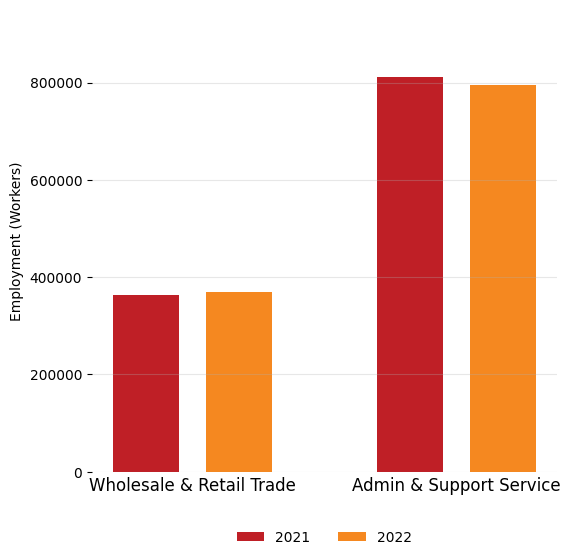

In [110]:
# Updated data from your provided table for the three sectors
sectors = ["Wholesale & Retail Trade", "Admin & Support Service"] 
demand_2022 = [370149, 794753]
demand_2021 = [362891, 810972]

x = np.arange(len(sectors)) # positions for sectors
width = 0.25  # width of bars

fig, ax = plt.subplots(figsize=(6, 6))
bars1 = ax.bar(x - width/2, demand_2021, width, label='2021', color='#bf1f26')
bars2 = ax.bar(x + width/2 + 0.1, demand_2022, width, label='2022', color='#f58820ff')

# Labels, title, etc.
ax.set_ylabel("Employment (Workers)")
ax.set_xticks(x + 0.05)
ax.set_xticklabels(sectors, rotation=0, ha='center', fontsize=12)

# Legend
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.1),
    ncol=2,
    frameon=False
)

# Style adjustments
ax.spines[['right', 'left', 'bottom', 'top']].set_visible(False)
ax.yaxis.grid(True, linestyle='-', alpha=0.3)

# Changing y-axis
ax.set_ylim(0, 950000)

ax.tick_params(axis='x', length=0)

# plt.tight_layout()
plt.show()

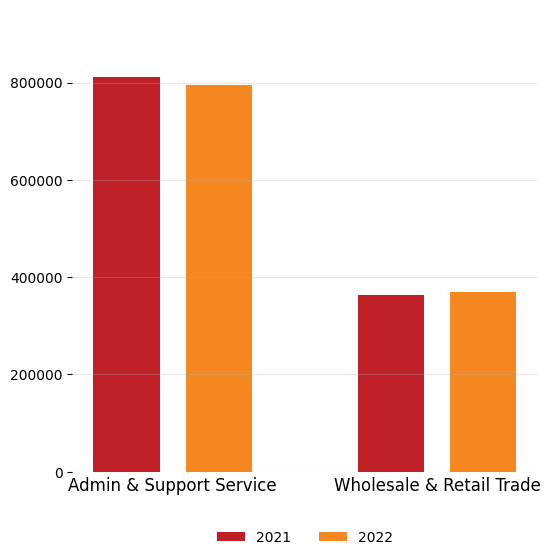

In [113]:
# Updated data from your provided table for the three sectors
sectors = ["Admin & Support Service", "Wholesale & Retail Trade"] 
demand_2022 = [794753, 370149]
demand_2021 = [810972, 362891]

x = np.arange(len(sectors)) # positions for sectors
width = 0.25  # width of bars

fig, ax = plt.subplots(figsize=(6, 6))
bars1 = ax.bar(x - width/2, demand_2021, width, label='2021', color='#bf1f26')
bars2 = ax.bar(x + width/2 + 0.1, demand_2022, width, label='2022', color='#f58820ff')

# Labels, title, etc.
# ax.set_ylabel()
ax.set_xticks(x + 0.05)
ax.set_xticklabels(sectors, rotation=0, ha='center', fontsize=12)

# Legend
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.1),
    ncol=2,
    frameon=False
)

# Style adjustments
ax.spines[['right', 'left', 'bottom', 'top']].set_visible(False)
ax.yaxis.grid(True, linestyle='-', alpha=0.3)

# Changing y-axis
ax.set_ylim(0, 950000)

ax.tick_params(axis='x', length=0)

# plt.tight_layout()
plt.show()

In [ ]:
# Annotate bar heights
def annotate_bars(bars):
    for b in bars:
        height = b.get_height()
        ax.annotate(f'{height:,}',
                    xy=(b.get_x() + b.get_width()/2, height),
                    xytext=(0, 0),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)

# annotate_bars(bars1)
# annotate_bars(bars2)
